# 5th Year MS Technical Report RQ2

## Setup

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sqlite3
import json
from enum import Enum

In [30]:
class Term(Enum):
    SPRING = 0
    SUMMER = 1
    FALL = 2

    def __str__(self):
        return self.name.capitalize()

    def short_name(self):
        if self == Term.SPRING:
            return "sp"
        elif self == Term.SUMMER:
            return "su"
        else:
            return "fa"


class Course:
    cs61a: bool
    term: Term
    year: int

    def __init__(self, cs61a: bool, term: Term, year: int):
        self.cs61a = cs61a
        self.term = term
        self.term_string = term.short_name() + str(year)[2:]
        self.year = year

    def __str__(self):
        return f"{'CS 61A' if self.cs61a else 'DATA C88C'} {self.term} {self.year}"

    def __repr__(self):
        return f"Course(cs61a={self.cs61a}, term={repr(self.term)}, year={self.year})"

    def __eq__(self, other):
        if isinstance(other, Course):
            return self.cs61a == other.cs61a and self.term == other.term and self.year == other.year
        return NotImplemented

    def __hash__(self):
        return hash(str(self))

In [31]:
courses = []

for year in (2024, 2025):
    for term in (Term.SPRING, Term.SUMMER, Term.FALL):
        for cs61a in (True, False):
            courses.append(Course(cs61a, term, year))

courses = [
    Course(True, Term.FALL, 2023),
    Course(False, Term.FALL, 2023),
] + courses

assert len(courses) == 14

for c in courses:
    print(c)

CS 61A Fall 2023
DATA C88C Fall 2023
CS 61A Spring 2024
DATA C88C Spring 2024
CS 61A Summer 2024
DATA C88C Summer 2024
CS 61A Fall 2024
DATA C88C Fall 2024
CS 61A Spring 2025
DATA C88C Spring 2025
CS 61A Summer 2025
DATA C88C Summer 2025
CS 61A Fall 2025
DATA C88C Fall 2025


In [32]:
PATH_PREFIX = "../../data/private/out"

def get_db_cursor(course: Course) -> tuple[sqlite3.Connection, sqlite3.Cursor]:
    conn = sqlite3.connect(f"{PATH_PREFIX}/{'cs61a' if course.cs61a else 'datac88c'}/{course.term_string}/snapshots.db")
    conn.row_factory = sqlite3.Row
    return conn, conn.cursor()

In [33]:
conns_curs = [get_db_cursor(course) for course in courses]
conns = [conn for conn, _ in conns_curs]
cursors = [cur for _, cur in conns_curs]

In [ ]:
results = {}

## How many backups are there per student?

In [ ]:
def backups_per_student(cur: sqlite3.Cursor) -> np.array:
    cur.execute("SELECT COUNT(*) FROM backup_metadata GROUP BY student_email")
    return np.array([row[0] for row in cur.fetchall()])

In [ ]:
results["backups_per_student"] = {}

for course, cur in zip(courses, cursors):
    results["backups_per_student"][course] = backups_per_student(cur)

<Axes: ylabel='Count'>

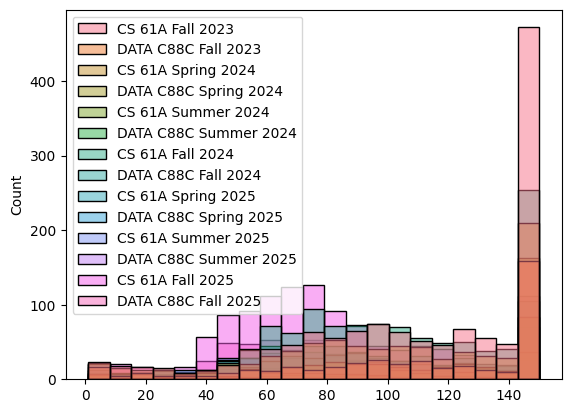

In [39]:
sns.histplot(data=results["backups_per_student"])

<Axes: ylabel='Count'>

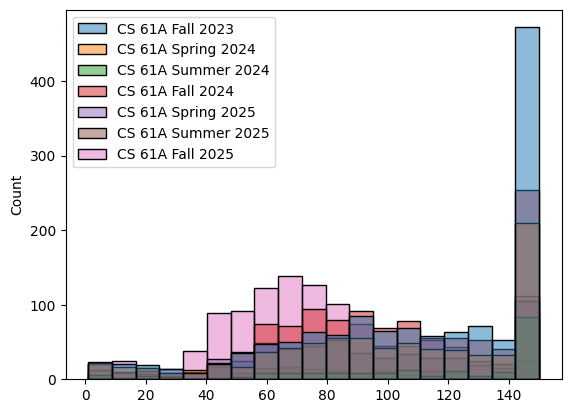

In [41]:
sns.histplot(data={key: val for key, val in results["backups_per_student"].items() if key.cs61a})

<Axes: ylabel='Count'>

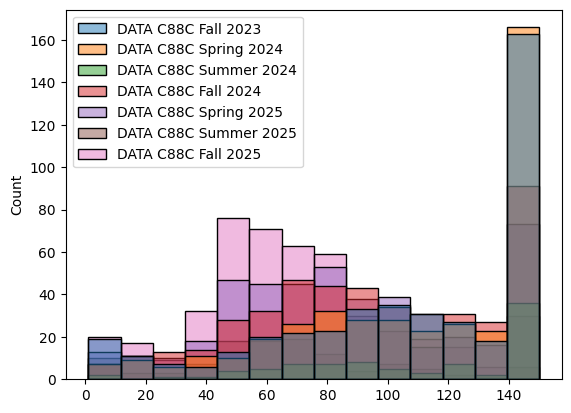

In [42]:
sns.histplot(data={key: val for key, val in results["backups_per_student"].items() if not key.cs61a})

<Axes: ylabel='Percent'>

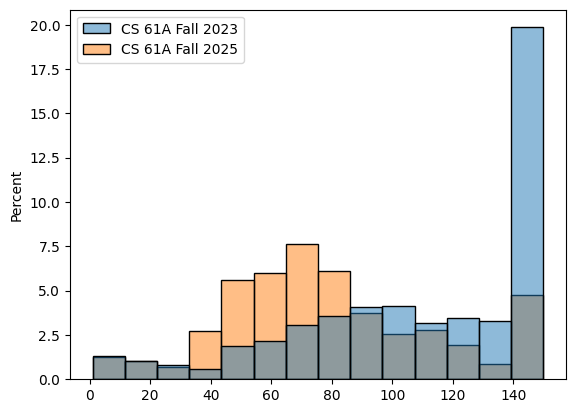

In [70]:
sns.histplot(data={
    key: val for key, val in results["backups_per_student"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL)) and key.cs61a},
    stat="percent",
)

<Axes: ylabel='Percent'>

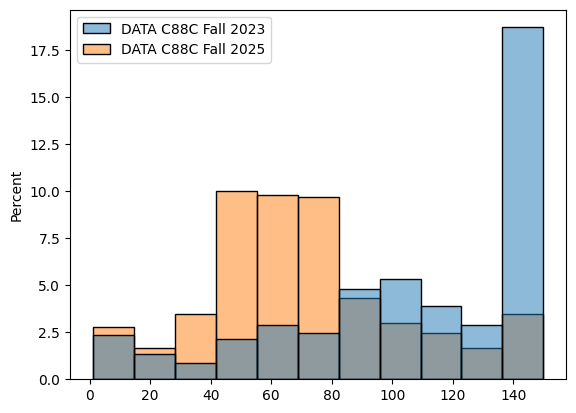

In [71]:
sns.histplot(data={
    key: val for key, val in results["backups_per_student"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL)) and not key.cs61a},
    stat="percent"
)

In [64]:
bps_median = {"Course": [], "Term": [], "Backups per student (median)": []}

for course, cur in zip(courses, cursors):
    bps_median["Course"].append('CS 61A' if course.cs61a else 'DATA C88C')
    bps_median["Term"].append(course.term_string.upper())
    bps_median["Backups per student (median)"].append(np.median(results["backups_per_student"][course]))

<Axes: xlabel='Term', ylabel='Backups per student (median)'>

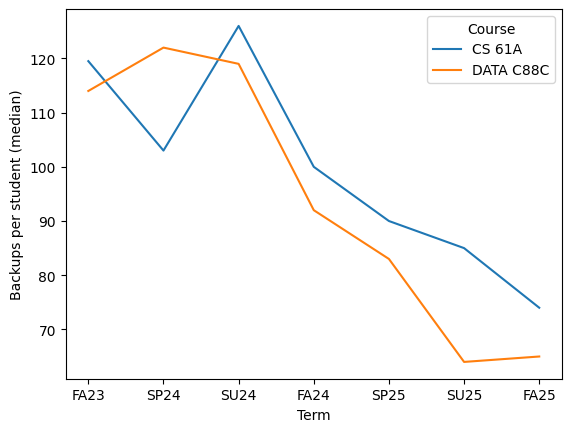

In [65]:
sns.lineplot(data=bps_median, x="Term", y="Backups per student (median)", hue="Course")

- Consistent downward trend in number of backups per student (caveat: ceiling effect due to limit 150 backups, but ceiling effect vanishes for sure by FA25)
- Only difference between courses: SP24. Possibly because 61Abot wide release that semester while C88C did not use it yet?

## Total time spent

## Total active time spent

## Problem(s) solved per day

## Autograder spam

## Teardown

In [ ]:
# Close db connection
for conn in conns:
    conn.close()